# Cifar10 데이터를 이용한 전이학습 실습

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# CIFAR-10 Dataset 가져오기
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()
print('x_train :', np.shape(train_images))
print('y_train :', np.shape(train_labels))
print('x_test :', np.shape(test_images))
print('y_test :', np.shape(test_labels))

x_train : (50000, 32, 32, 3)
y_train : (50000, 1)
x_test : (10000, 32, 32, 3)
y_test : (10000, 1)


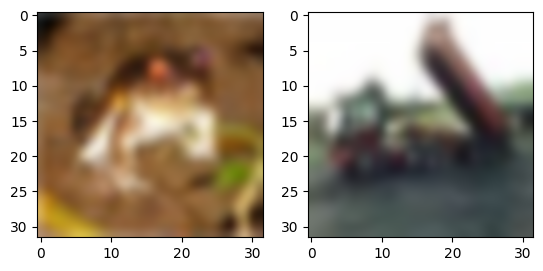

In [3]:
# 이미지 예제 시각화
plt.subplot(121)
plt.imshow(train_images[0], interpolation="bicubic")
plt.grid(False)
plt.subplot(122)
plt.imshow(train_images[2], interpolation="bicubic")
plt.grid(False)
plt.show()

In [4]:
# 이미지 데이터 정규화 및 전처리
train_images = preprocess_input(train_images)
test_images = preprocess_input(test_images)

# 레이블을 원-핫 인코딩
train_labels = to_categorical(train_labels, 10)
test_labels = to_categorical(test_labels, 10)

In [5]:
print(train_images.shape)

(50000, 32, 32, 3)


In [7]:
# 미리 학습된 VGG16 모델 불러오기 (최상위 레이어는 포함하지 않음)
vgg16 = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# VGG16 모델의 레이어를 동결 (학습되지 않도록 설정)
for layer in vgg16.layers:
    layer.trainable = False

In [8]:
# Sequential 모델 구성
model = Sequential()
model.add(vgg16)
model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# 모델 컴파일
model.compile(optimizer=Adam(),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 모델 학습
history = model.fit(train_images, train_labels, epochs=10, batch_size=32, validation_data=(test_images, test_labels))

Epoch 1/10
 162/1563 ━━━━━━━━━━━━━━━━━━━━ 11:00 472ms/step - accuracy: 0.1818 - loss: 24.7018

KeyboardInterrupt: 

In [ ]:
# 학습 결과 시각화
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Training accuracy')
    plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

plot_history(history)


# CNN을 이용한 개/고양이 이미지 분류 모델


In [ ]:
#압축파일 해제
import zipfile
zipfile.ZipFile('Dataset.zip').extractall()

In [ ]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

#import shutil
#shutil.rmtree('PetImages/') #폴더 삭제 코드 (코딩x)

경로 지정 & model build

In [9]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Dropout, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#경로 파일
src = 'PetImages/'

# 초매개변수 정의
FILTER_SIZE = 3
NUM_FILTERS = 32
INPUT_SIZE  = 32
MAXPOOL_SIZE = 2
BATCH_SIZE = 16
EPOCHS = 10

model = Sequential()
model.add(Conv2D(NUM_FILTERS, (FILTER_SIZE, FILTER_SIZE), input_shape = (INPUT_SIZE, INPUT_SIZE, 3), activation = 'relu'))
model.add(MaxPooling2D(pool_size = (MAXPOOL_SIZE, MAXPOOL_SIZE)))
model.add(Conv2D(NUM_FILTERS, (FILTER_SIZE, FILTER_SIZE), activation = 'relu'))
model.add(MaxPooling2D(pool_size = (MAXPOOL_SIZE, MAXPOOL_SIZE)))
model.add(Flatten())
model.add(Dense(units = 1, activation = 'sigmoid'))
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │           1,153 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,297 (44.13 KB)

 Trainable params: 11,297 (44.13 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
training_data_generator = ImageDataGenerator(rescale = 1./255)
testing_data_generator = ImageDataGenerator(rescale = 1./255)

training_set = training_data_generator.flow_from_directory(src+'Train/',
                                                target_size = (INPUT_SIZE, INPUT_SIZE),
                                                batch_size = BATCH_SIZE,
                                                class_mode = 'binary')

test_set = testing_data_generator.flow_from_directory(src+'Test/',
                                             target_size = (INPUT_SIZE, INPUT_SIZE),
                                             batch_size = BATCH_SIZE,
                                             class_mode = 'binary')
print(training_set)

model.fit(training_set,epochs = EPOCHS, verbose=1)

score = model.evaluate(test_set)

for idx, metric in enumerate(model.metrics_names):
    print("{}: {}".format(metric, score[idx]))

Found 300 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.5284 - loss: 0.7028
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4908 - loss: 0.6908
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5631 - loss: 0.6848
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6523 - loss: 0.6770
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6259 - loss: 0.6654
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6567 - loss: 0.6555
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7499 - loss: 0.6363
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7388 - loss: 0.6111
Epoch 9/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.6982 - loss: 0.5939
Epoch 10/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7610 - loss: 0.5589
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6447 - loss: 0.6531
loss: 0.6671398878097534
compile_metrics: 0.6100000143051147


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


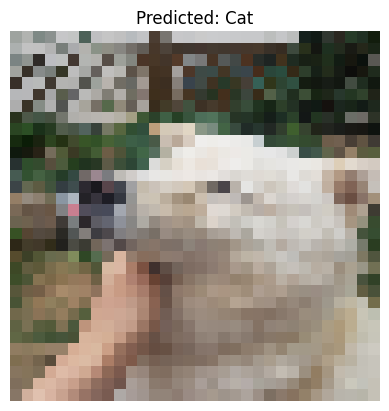

In [11]:
import numpy as np
from keras.preprocessing import image
import matplotlib.pyplot as plt

# 이미지 파일 경로
image_path = '3.jpg'

# 이미지를 로드하고 전처리하는 함수
def load_and_preprocess_image(image_path, target_size):
    img = image.load_img(image_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # 모델 입력 형태에 맞게 차원 추가
    img_array /= 255.0  # 이미지를 스케일링
    return img, img_array

# 이미지를 로드하고 전처리
img, processed_img = load_and_preprocess_image(image_path, (INPUT_SIZE, INPUT_SIZE))

# 모델을 사용하여 예측
prediction = model.predict(processed_img)
prediction_class = 'Dog' if prediction[0] > 0.5 else 'Cat'

# 결과를 시각화
plt.imshow(img)
plt.title(f'Predicted: {prediction_class}')
plt.axis('off')
plt.show()


# 동물 데이터를 이용한 전이학습 실습

In [13]:
from keras.applications.vgg16 import VGG16
from keras.models import Model
from keras.layers import Dense, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 초매개변수 정의
INPUT_SIZE = 32
BATCH_SIZE = 15
EPOCHS = 10

#경로 파일
src = 'PetImages/'

ver1_기존 학습된 신경망(vgg16)을 그대로 이용

In [14]:
vgg16 = VGG16(include_top=False, weights='imagenet', input_shape=(INPUT_SIZE,INPUT_SIZE,3))

# 사전 학습된 레이어 고정
for layer in vgg16.layers:
    layer.trainable = False

# 신경망 맨 오른쪽에 노드 1개짜리 완전 연결 레이어 추가
print(vgg16.input)
input_ = vgg16.input
output_ = vgg16(input_)
last_layer = Flatten(name='flatten')(output_)
last_layer = Dense(1, activation='sigmoid')(last_layer)


model = Model(inputs=input_, outputs=last_layer)
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
model.summary()

<KerasTensor shape=(None, 32, 32, 3), dtype=float32, sparse=None, name=keras_tensor_87>


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg16 (Functional)                   │ (None, 1, 1, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,715,201 (56.13 MB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [15]:
training_data_generator = ImageDataGenerator(rescale = 1./255)
testing_data_generator = ImageDataGenerator(rescale = 1./255)

training_set = training_data_generator.flow_from_directory(src+'Train/',
                                                target_size = (INPUT_SIZE, INPUT_SIZE),
                                                batch_size = BATCH_SIZE,
                                                class_mode = 'binary')

test_set = testing_data_generator.flow_from_directory(src+'Test/',
                                             target_size = (INPUT_SIZE, INPUT_SIZE),
                                             batch_size = BATCH_SIZE,
                                             class_mode = 'binary')

model.fit(training_set, epochs = EPOCHS, verbose=1)

score = model.evaluate(test_set)

for idx, metric in enumerate(model.metrics_names):
    print("{}: {}".format(metric, score[idx]))

Found 300 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 258ms/step - accuracy: 0.4778 - loss: 0.7516
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 219ms/step - accuracy: 0.5876 - loss: 0.6850
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 206ms/step - accuracy: 0.5855 - loss: 0.6623
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 301ms/step - accuracy: 0.6526 - loss: 0.6480
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 192ms/step - accuracy: 0.6481 - loss: 0.6316
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 194ms/step - accuracy: 0.6319 - loss: 0.6367
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 240ms/step - accuracy: 0.6603 - loss: 0.6161
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 195ms/step - accuracy: 0.6535 - loss: 0.5981
Epoch 9/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 221ms/step - accuracy: 0.6819 - loss: 0.6013
Epoch 10/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 246ms/step - accuracy: 0.6953 - loss: 0.5909
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 191ms/step - accuracy: 0.6575

ver2_vgg16의 마지막 3개 layer는 학습 (fine-tuning)

In [16]:
from keras.applications.vgg16 import VGG16
from keras.models import Model
from keras.layers import Dense, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 초매개변수 정의
INPUT_SIZE = 32
BATCH_SIZE = 15
EPOCHS = 10

#경로 파일
src = 'PetImages/'
vgg16 = VGG16(include_top=False, weights='imagenet', input_shape=(INPUT_SIZE,INPUT_SIZE,3))

# 사전 학습된 레이어 고정
for layer in vgg16.layers[:-3]:
    layer.trainable = False

# 신경망 맨 오른쪽에 노드 1개짜리 완전 연결 레이어 추가
print(vgg16.input)
input_ = vgg16.input
output_ = vgg16(input_)
last_layer = Flatten(name='flatten')(output_)
last_layer = Dense(1, activation='sigmoid')(last_layer)
model = Model(inputs=input_, outputs=last_layer)
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
model.summary()

training_data_generator = ImageDataGenerator(rescale = 1./255)
testing_data_generator = ImageDataGenerator(rescale = 1./255)

training_set = training_data_generator.flow_from_directory(src+'Train/',
                                                target_size = (INPUT_SIZE, INPUT_SIZE),
                                                batch_size = BATCH_SIZE,
                                                class_mode = 'binary')

test_set = testing_data_generator.flow_from_directory(src+'Test/',
                                             target_size = (INPUT_SIZE, INPUT_SIZE),
                                             batch_size = BATCH_SIZE,
                                             class_mode = 'binary')

model.fit(training_set, epochs = EPOCHS, verbose=1)
score = model.evaluate(test_set)

for idx, metric in enumerate(model.metrics_names):
    print("{}: {}".format(metric, score[idx]))

<KerasTensor shape=(None, 32, 32, 3), dtype=float32, sparse=None, name=keras_tensor_109>


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)           │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg16 (Functional)                   │ (None, 1, 1, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,715,201 (56.13 MB)

 Trainable params: 4,720,129 (18.01 MB)

 Non-trainable params: 9,995,072 (38.13 MB)

Found 300 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 533ms/step - accuracy: 0.5483 - loss: 0.9240
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 598ms/step - accuracy: 0.6174 - loss: 0.6100
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 612ms/step - accuracy: 0.7238 - loss: 0.5275
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 585ms/step - accuracy: 0.8189 - loss: 0.4125
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 613ms/step - accuracy: 0.8416 - loss: 0.3533
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 599ms/step - accuracy: 0.8665 - loss: 0.2959
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 764ms/step - accuracy: 0.8829 - loss: 0.2463
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 612ms/step - accuracy: 0.8647 - loss: 0.2978
Epoch 9/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 594ms/step - accuracy: 0.8836 - loss: 0.2565
Epoch 10/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 575ms/step - accuracy: 0.9623 - loss: 0.0939
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 185ms/step - accura

In [ ]:
from keras.applications.resnet import ResNet50
from keras.models import Model
from keras.layers import Dense, Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 초매개변수 정의
INPUT_SIZE = 32
BATCH_SIZE = 15
EPOCHS = 10

#경로 파일
src = 'PetImages/'
resnet50 = ResNet50(include_top=False, weights='imagenet', input_shape=(INPUT_SIZE,INPUT_SIZE,3))

# 사전 학습된 레이어 고정
for layer in resnet50.layers[:-3]:
    layer.trainable = False

# 신경망 맨 오른쪽에 노드 1개짜리 완전 연결 레이어 추가
print(resnet50.input)
input_ = resnet50.input
output_ = resnet50(input_)
last_layer = Flatten(name='flatten')(output_)
last_layer = Dense(1, activation='sigmoid')(last_layer)
model = Model(inputs=input_, outputs=last_layer)
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
model.summary()

training_data_generator = ImageDataGenerator(rescale = 1./255)
testing_data_generator = ImageDataGenerator(rescale = 1./255)

training_set = training_data_generator.flow_from_directory(src+'Train/',
                                                target_size = (INPUT_SIZE, INPUT_SIZE),
                                                batch_size = BATCH_SIZE,
                                                class_mode = 'binary')

test_set = testing_data_generator.flow_from_directory(src+'Test/',
                                             target_size = (INPUT_SIZE, INPUT_SIZE),
                                             batch_size = BATCH_SIZE,
                                             class_mode = 'binary')

model.fit(training_set, epochs = EPOCHS, verbose=1)
score = model.evaluate(test_set)

for idx, metric in enumerate(model.metrics_names):
    print("{}: {}".format(metric, score[idx]))

94765736/94765736 [==============================] - 1s 0us/step
KerasTensor(type_spec=TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='input_34'), name='input_34', description="created by layer 'input_34'")
Model: "model_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_34 (InputLayer)       [(None, 32, 32, 3)]       0         
                                                                 
 resnet50 (Functional)       (None, 1, 1, 2048)        23587712  
                                                                 
 flatten (Flatten)           (None, 2048)              0         
                                                                 
 dense_6 (Dense)             (None, 1)                 2049      
                                                                 
Total params: 23589761 (89.99 MB)
Trainable params: 6145 (24.00 KB)
Non-trainable params: 23583616 (89.9

<ipython-input-42-23af1e7c7271>:42: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  model.fit_generator(training_set, epochs = EPOCHS, verbose=1)


20/20 [==============================] - 6s 92ms/step - loss: 0.7745 - accuracy: 0.5000
Epoch 2/10
20/20 [==============================] - 2s 106ms/step - loss: 0.6954 - accuracy: 0.5433
Epoch 3/10
20/20 [==============================] - 3s 145ms/step - loss: 0.6361 - accuracy: 0.6300
Epoch 4/10
20/20 [==============================] - 2s 97ms/step - loss: 0.6562 - accuracy: 0.6100
Epoch 5/10
20/20 [==============================] - 2s 94ms/step - loss: 0.6355 - accuracy: 0.6400
Epoch 6/10
20/20 [==============================] - 2s 94ms/step - loss: 0.6162 - accuracy: 0.6767
Epoch 7/10
20/20 [==============================] - 2s 92ms/step - loss: 0.6450 - accuracy: 0.5967
Epoch 8/10
20/20 [==============================] - 3s 150ms/step - loss: 0.5763 - accuracy: 0.6967
Epoch 9/10
20/20 [==============================] - 2s 92ms/step - loss: 0.5707 - accuracy: 0.7067
Epoch 10/10
20/20 [==============================] - 2s 93ms/step - loss: 0.5841 - accuracy: 0.6667


<ipython-input-42-23af1e7c7271>:43: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  score = model.evaluate_generator(test_set)


loss: 0.688606858253479
accuracy: 0.5299999713897705
